In [22]:
import sys
sys.path.insert(0, '..')

from pathlib import Path
from brainrender._io import load_mesh_from_file
from myterial import orange
from rich import print
from brainglobe_atlasapi import BrainGlobeAtlas
from brainrender import Scene
import brainrender
from brainrender.actors import Points, Line
import numpy as np
from utils import slice_util
from PIL import Image
import os
import subprocess
import  vedo 
import pandas as pd
import brainglobe_heatmap as bgh
import matplotlib.pyplot as plt
import matplotlib

In [3]:
bg_atlas = BrainGlobeAtlas("allen_mouse_50um", check_latest=False)
#bg_atlas.lookup_df.acronym.values
#regions = ['root']
#obj_file_names = [ str(bg_atlas.meshfile_from_structure(region)) for region in regions ]
#combined_obj_file_name = 'output/combined.obj'
#slice_util.combine_obj_file_list(obj_file_names,combined_obj_file_name)
#root_mesh = load_mesh_from_file(combined_obj_file_name, alpha=0.1, color="black")

In [4]:
bg_atlas.structures['688']


{
    'acronym': 'CTX',
    'id': 688,
    'name': 'Cerebral cortex',
    'structure_id_path': [997, 8, 567, 688],
    'rgb_triplet': [176, 255, 184],
    'mesh_filename': WindowsPath('C:/Users/jhahn/.brainglobe/allen_mouse_50um_v1.2/meshes/688.obj'),
    'mesh': <meshio mesh object>
  Number of points: 52238
  Number of cells:
    triangle: 104321
  Point data: obj:vn
  Cell data: obj:group_ids
}

In [ ]:
df_fold =  pd.read_csv('resources/fold.csv')
df_id_name = pd.read_csv('resources/id_name.csv')
df_fold.set_index("TG number", inplace=True)
id_2_name = {}
name_2_id = {}
for _i, _row in df_id_name[['Region ID','Region name']].iterrows():
    id_2_name[_row['Region ID']] = _row['Region name']
    name_2_id[_row['Region name']] = _row['Region ID']


In [6]:
bg_atlas.structures


root (997)
├── VS (73)
│   ├── AQ (140)
│   ├── V3 (129)
│   ├── V4 (145)
│   │   └── V4r (153)
│   ├── VL (81)
│   │   ├── SEZ (98)
│   │   └── chpl (108)
│   └── c (164)
├── fiber tracts (1009)
│   ├── cbf (960)
│   │   ├── arb (728)
│   │   ├── cbc (744)
│   │   └── cbp (752)
│   │       ├── icp (1123)
│   │       │   └── sctd (553)
│   │       ├── mcp (78)
│   │       └── scp (326)
│   │           ├── dscp (812)
│   │           ├── sctv (866)
│   │           └── uf (850)
│   ├── cm (967)
│   │   ├── IIIn (832)
│   │   │   ├── mlf (62)
│   │   │   └── pc (158)
│   │   ├── IIn (848)
│   │   │   ├── bsc (916)
│   │   │   ├── csc (336)
│   │   │   ├── och (117)
│   │   │   └── opt (125)
│   │   ├── IVn (911)
│   │   ├── In (840)
│   │   │   ├── aco (900)
│   │   │   ├── lotg (21)
│   │   │   │   ├── lot (665)
│   │   │   │   └── lotd (538)
│   │   │   └── onl (1016)
│   │   ├── VIIIn (933)
│   │   │   ├── cVIIIn (948)
│   │   │   │   ├── bic (482)
│   │   │   │   ├── cic (633)
│   │  

In [7]:
data_dict_up = {}
data_dict_down = {}
not_found_region = []
for tg_name, _row in df_fold[['cor_PV']].iterrows():
    if tg_name in ['root','grey','fiber tracts','VS']:
        continue
    _id = name_2_id[tg_name]
    try:
        value = bg_atlas.structures[str(_id)]
        if abs(_row['cor_PV']) != np.inf:
            if _row['cor_PV'] >= 2.0:
                data_dict_up[value['acronym']] = _row['cor_PV']
            elif _row['cor_PV'] <= -2.0:
                data_dict_down[value['acronym']] = _row['cor_PV']
        
    except:
        not_found_region.append(_id)
print(len(data_dict_up),len(data_dict_down))


23 46

In [8]:
bgh.get_structures_slice_coords("root")

TypeError: get_structures_slice_coords() missing 1 required positional argument: 'position'

C:\Users\jhahn\AppData\Local\Temp\ipykernel_11616\780183831.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  matplotlib.cm.get_cmap('Blues')


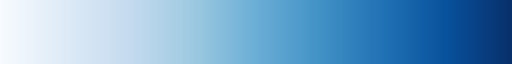

In [26]:
matplotlib.cm.get_cmap('Blues')

frontal 10

sagittal 10

horizontal 10

frontal 10

sagittal 10

horizontal 10

C:\Users\jhahn\AppData\Local\Temp\ipykernel_11616\1186540265.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 640x480 with 0 Axes>

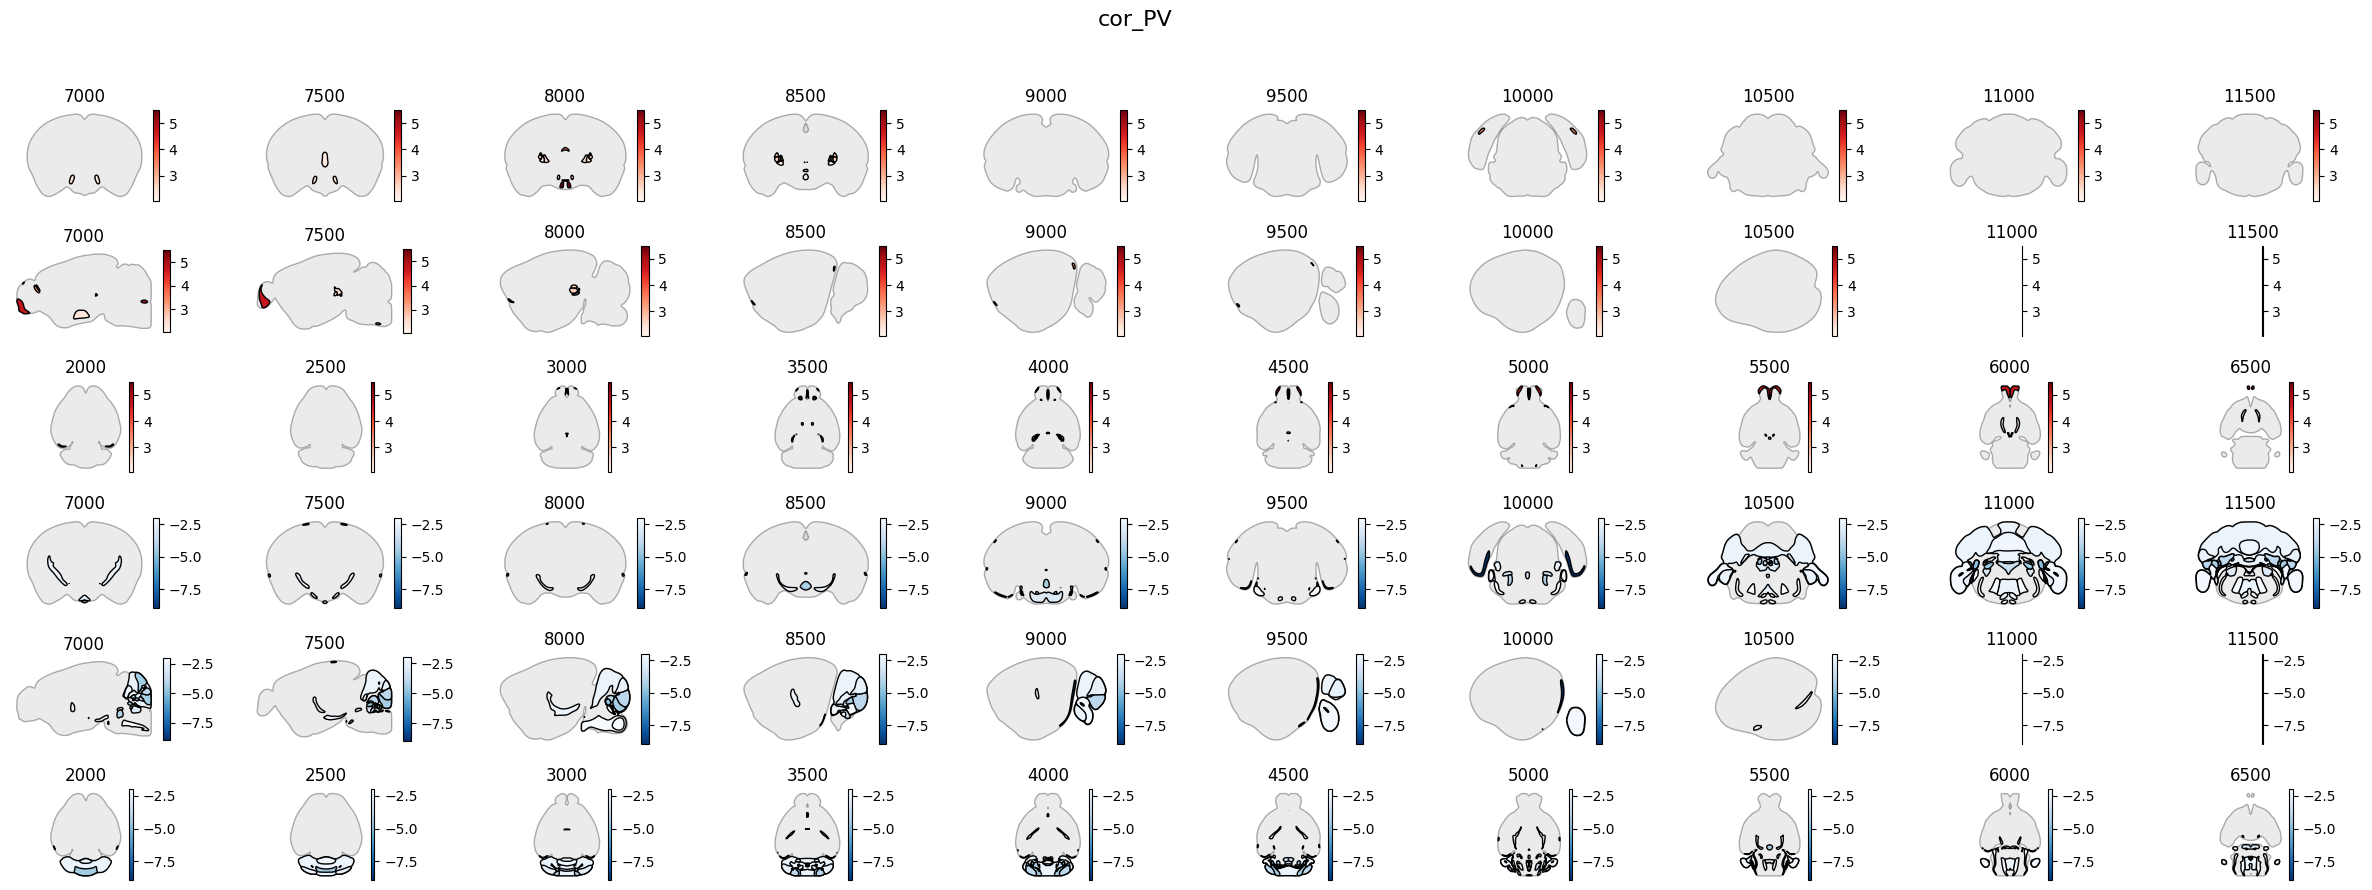

In [ ]:
from matplotlib import gridspec

# Create a list of scenes to plot
# Note: it's important to keep reference to the scenes to avoid a
# segmentation fault
plt.clf()
# Create a figure with 6 subplots and plot the scenes
color_code = 'cor_PV'
fig = plt.figure(figsize=(30, 10))
#fig, axs = plt.subplots(2,7, figsize=(30, 10))
fig.suptitle(f'{color_code}', fontsize=16)
spec = gridspec.GridSpec(ncols=10, nrows=6,
                         width_ratios=[1,1, 1, 1, 1, 1, 1, 1, 1, 1], wspace=0.5,
                         hspace=0.5)


ax_row_index = 0
ax_col_index = 0
spec_index = 0
for subtitle, color, data_dict in [('Fold > 2','Reds',data_dict_up),('Fold < 2',"Blues_r",data_dict_down)]:
    
    #ax_col_index = 0
    #ax = fig.add_subplot(spec[ax_row_index:ax_row_index+3,ax_col_index])
    #ax.set_axis_off()
    #ax.text(0.5, 0.5,f'{subtitle}',  fontsize = 20)
    
    _max = np.max(list(data_dict.values()))
    _min = np.min(list(data_dict.values()))
    
    
    # AP Frontal 12000
    # LR saggital 11400
    # DV horizontal 7000
    for cut, min_dist, max_dist, gap in [('frontal',7000,12000,500),('sagittal',6000,12000,500),('horizontal',2000,7000,500)]:
        
        ax_col_index = 0
        
        #ax = fig.add_subplot(spec[ax_row_index,ax_col_index])        
        #ax.set_axis_off()
        #ax.text(0.5, 0.5,f'{cut}',  fontsize = 20)
        
    #distance_list = list(range(7500, 10500, 500))
        distance_list = list(range(min_dist, max_dist, gap))
        print(cut, len(distance_list))
        
        for distance in distance_list[:10]:
            

            scene = bgh.Heatmap(
                data_dict,
                position=distance,
                orientation=cut,
                thickness=10,
                format="2D",
                cmap= color,
                vmin= _min,
                vmax= _max,
                label_regions=False,
                interactive = False
            )

            #ax = axs[ax_row_index,ax_col_index]
            ax = fig.add_subplot(spec[ax_row_index, ax_col_index])
            ax_col_index += 1
            scene.plot_subplot(fig=fig, ax=ax, show_cbar=True, hide_axes=True)
            ax.set_title(f'{distance}')
        
        ax_row_index += 1

plt.tight_layout()
#plt.show()
fig.savefig('output/heatmap.png', dpi=300, bbox_inches='tight', pad_inches=0)

In [10]:
regions = [('TH',0.5),("CA1",0.6)]

output/0.png

Saving new screenshot at output\0.png

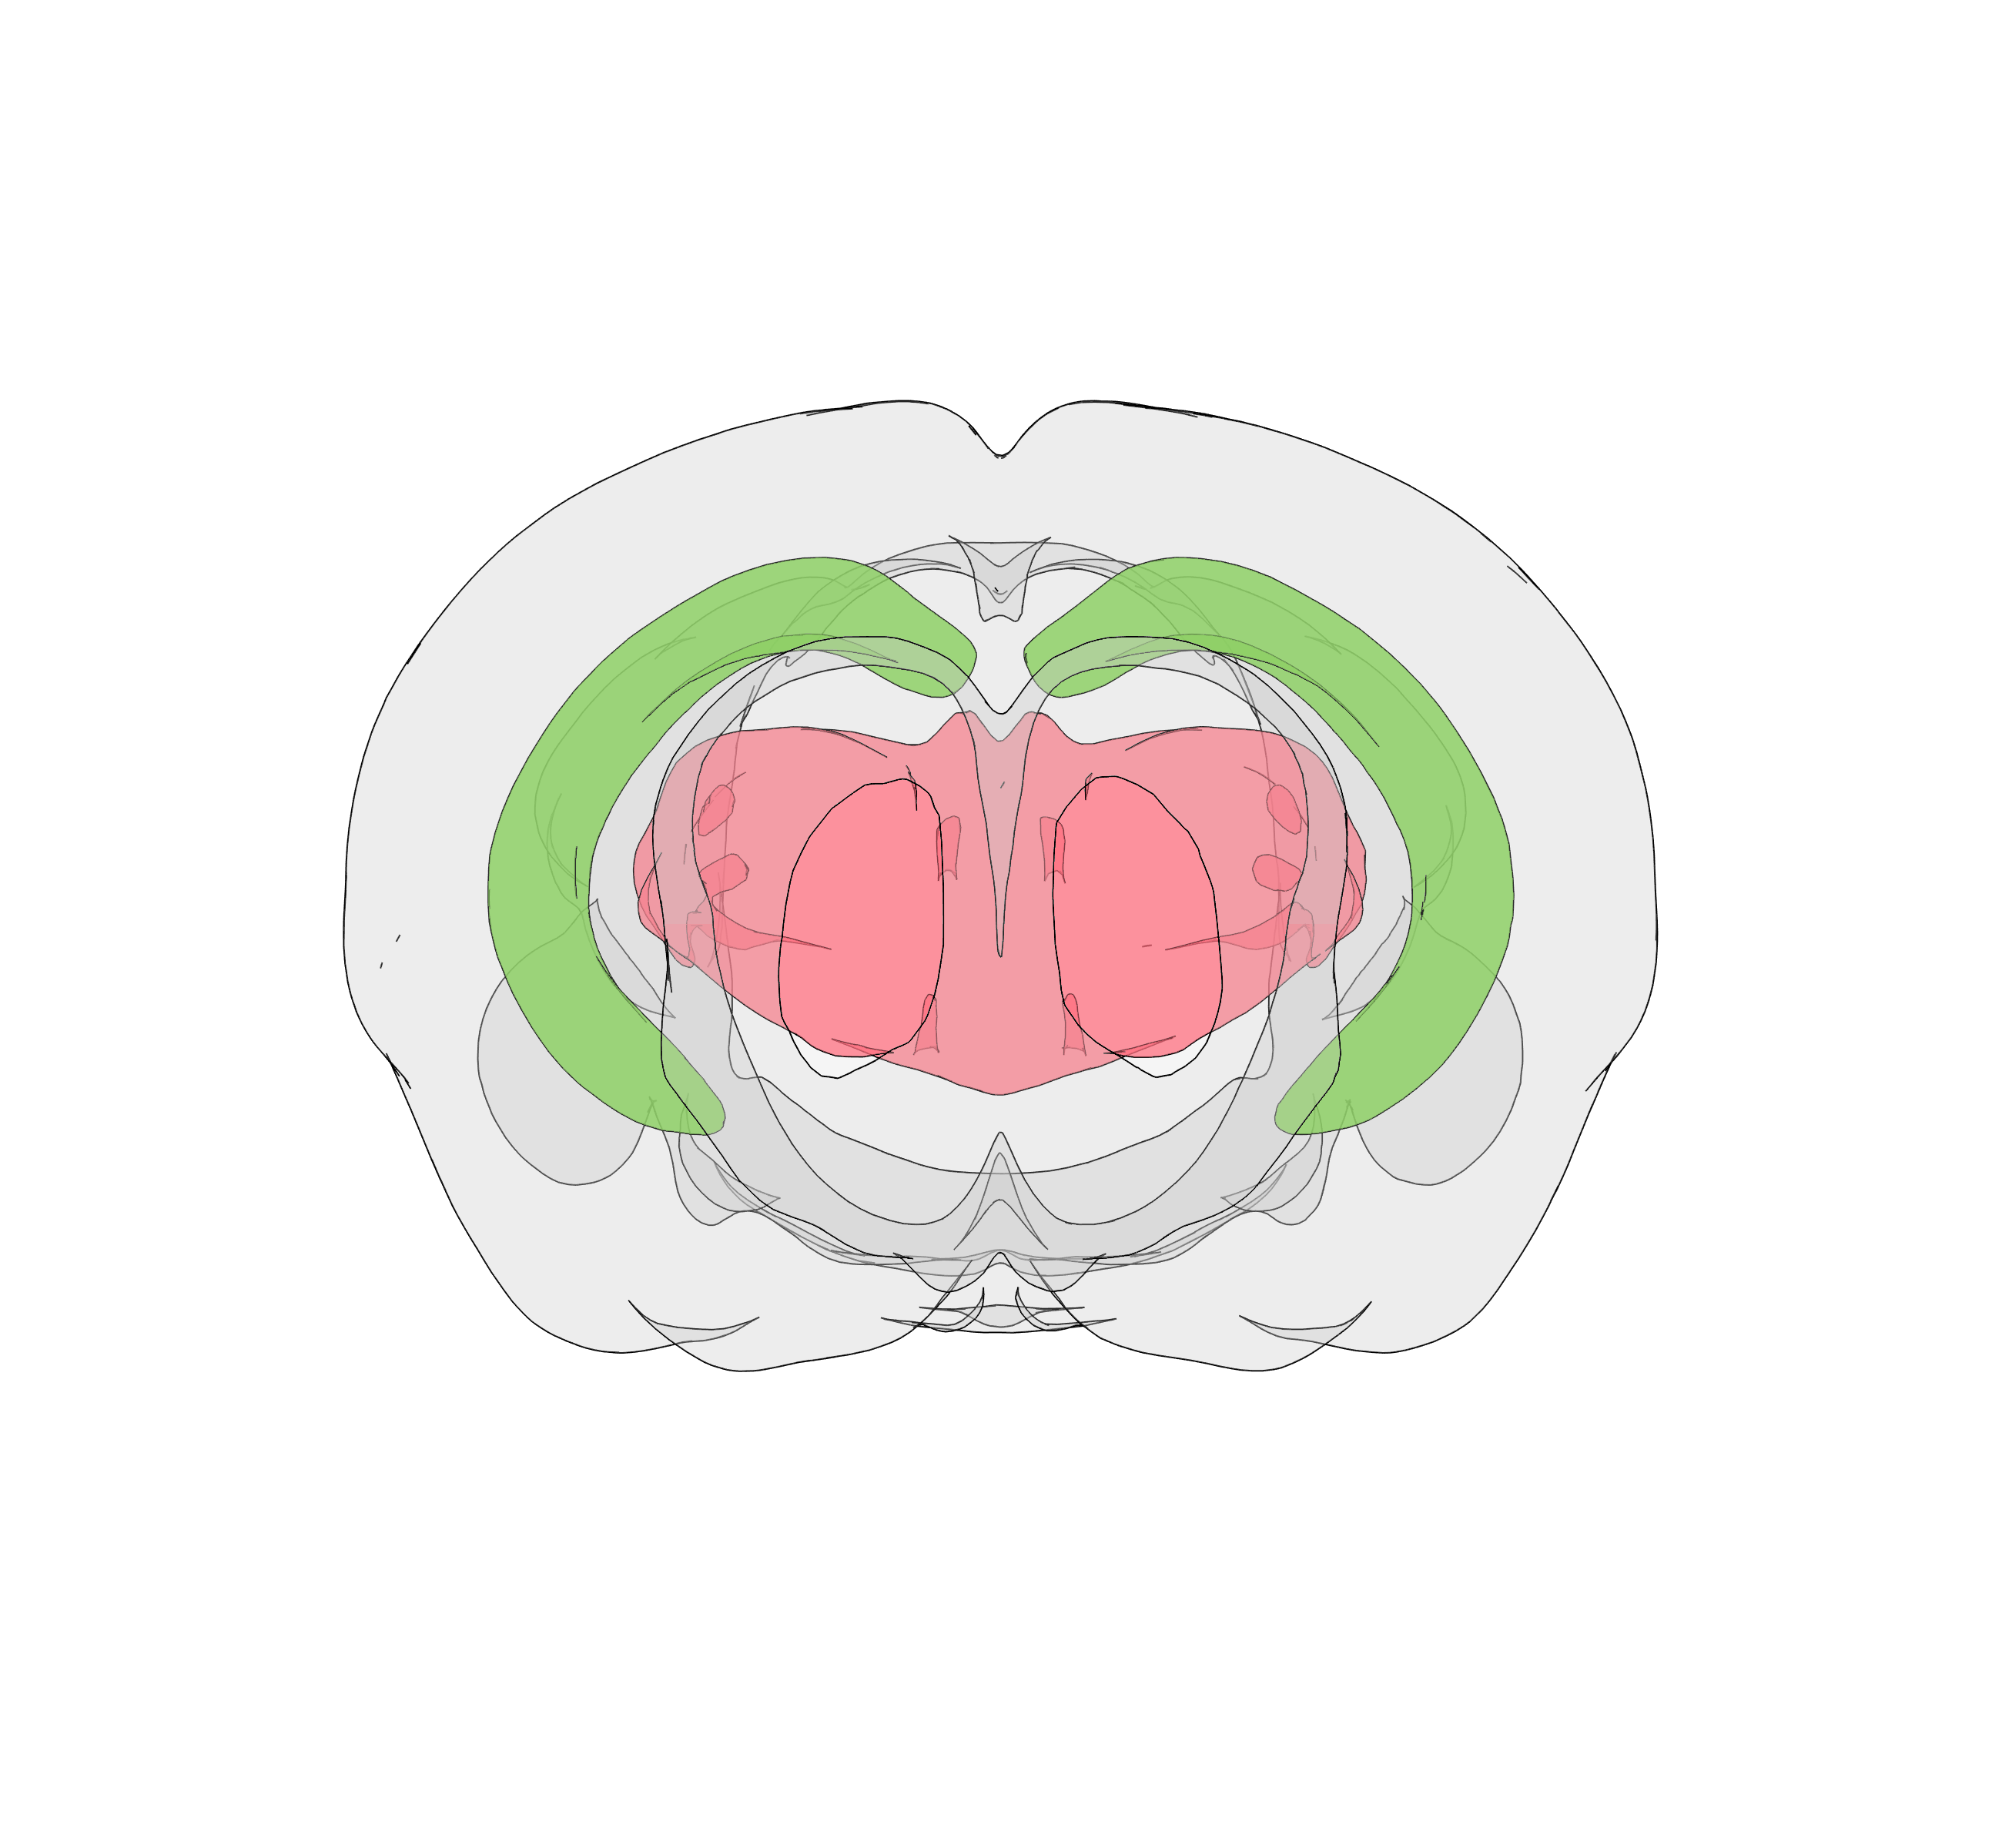

In [15]:
output_dir = 'output'
brainrender.settings.SHOW_AXES = False  # reset axes display
brainrender.settings.WHOLE_SCREEN = (
    False  # make the rendering window be smaller
)


# Create a brainrender scene
#scene = Scene(title="slice")
scene = Scene(title="", atlas_name="allen_mouse_25um")
# Add brain regions
for region, alpha in regions:
    scene.add_brain_region(region, alpha=alpha)
cut_x = 0
center_of_cut_plane = [cut_x,0,0]
#center_of_cut_plane = mesh.center_of_mass()
plane = scene.atlas.get_plane(pos=center_of_cut_plane, norm=(1, 0, 0))
scene.slice(plane)

#print(mesh.center_of_mass())

focal_point = (-1000, root_mesh.center_of_mass()[1],  -root_mesh.center_of_mass()[2])

#points = Points(np.array([focal_point]), radius=100, colors="blue")
#scene.add(points)

# Set up a camera. Can use string, such as "sagittal".
# During render runtime, press "c" to print the current camera parameters.
camera = {
    "pos": (-20000, root_mesh.center_of_mass()[1],  -root_mesh.center_of_mass()[2]),
    "viewup": (0, -1, 0),
    "clipping_range": (-4000,2000),
    "focal_point": focal_point,
    "distance": 2000,
}
zoom = -1000

# If you only want a screenshot and don't want to move the camera
# around the scene, set interactive to False.
scene.render(interactive=True, camera=camera, zoom=zoom)

# Set the scale, which will be used for screenshot resolution.
# Any value > 1 increases resolution, the default is in brainrender.settings.
# It is easiest integer scales (non-integer can cause crashes).
scale = 2
filename = f"{output_dir}/{cut_x}.png"
print(filename)
# Take a screenshot - passing no name uses current time
# Screenshots can be also created during runtime by pressing "s"
scene.screenshot(name=filename, scale=scale)
#scene.close()

crop(filename,300)



display.Image(filename=filename) 

In [9]:
bg_atlas.lookup_df.acronym.values


array(['root', 'grey', 'CH', 'CTX', 'CTXpl', 'Isocortex', 'FRP', 'FRP1',
       'FRP2/3', 'FRP5', 'FRP6a', 'FRP6b', 'MO', 'MOp', 'MOp1', 'MOp2/3',
       'MOp5', 'MOp6a', 'MOp6b', 'MOs', 'MOs1', 'MOs2/3', 'MOs5', 'MOs6a',
       'MOs6b', 'SS', 'SSp', 'SSp-n', 'SSp-n1', 'SSp-n2/3', 'SSp-n4',
       'SSp-n5', 'SSp-n6a', 'SSp-n6b', 'SSp-bfd', 'SSp-bfd1',
       'SSp-bfd2/3', 'SSp-bfd4', 'SSp-bfd5', 'SSp-bfd6a', 'SSp-bfd6b',
       'SSp-ll', 'SSp-ll1', 'SSp-ll2/3', 'SSp-ll4', 'SSp-ll5', 'SSp-ll6a',
       'SSp-ll6b', 'SSp-m', 'SSp-m1', 'SSp-m2/3', 'SSp-m4', 'SSp-m5',
       'SSp-m6a', 'SSp-m6b', 'SSp-ul', 'SSp-ul1', 'SSp-ul2/3', 'SSp-ul4',
       'SSp-ul5', 'SSp-ul6a', 'SSp-ul6b', 'SSp-tr', 'SSp-tr1',
       'SSp-tr2/3', 'SSp-tr4', 'SSp-tr5', 'SSp-tr6a', 'SSp-tr6b',
       'SSp-un', 'SSp-un1', 'SSp-un2/3', 'SSp-un4', 'SSp-un5', 'SSp-un6a',
       'SSp-un6b', 'SSs', 'SSs1', 'SSs2/3', 'SSs4', 'SSs5', 'SSs6a',
       'SSs6b', 'GU', 'GU1', 'GU2/3', 'GU4', 'GU5', 'GU6a', 'GU6b',
       'VISC',

In [ ]:

brainrender.settings.SHOW_AXES = True  # reset axes display
brainrender.settings.WHOLE_SCREEN = (
    False  # make the rendering window be smaller
)
output_dir = 'output'

import matplotlib.pyplot as plt
import os

fig, axs = plt.subplots(2,5,figsize=(15,5))
file_list = os.listdir(output_dir)
file_list.sort(key=lambda x : int(x.split(".")[0]))

row_index = 0
col_index = 0
for file in file_list:
    i = Image.open(output_dir+"/"+file)
    #iar = np.array(i)
    axs[row_index,col_index].imshow(i)
    axs[row_index,col_index].set_title(file.split(".")[0]+" um")
    axs[row_index,col_index].set_axis_off()
    col_index += 1
    if col_index >= 5:
        col_index = 0
        row_index += 1
plt.show()
fig.savefig('total.png', dpi=300, bbox_inches='tight', pad_inches=0)
#axs[0].plot(Y)
#axs[1].scatter(z['level_1'], z['level_0'],c=z[0])

In [ ]:

#for cut_x in range(2000,11001,1000):
for cut_x in [0]:
        
    # Create a brainrender scene
    #scene = Scene(title="slice")
    scene = Scene(title="", atlas_name="allen_mouse_25um")
    # Add brain regions
    th = scene.add_brain_region("TH")
    #scene.add_label(th, "TH")
    # You can specify color, transparency...
    #mos, ca1 = scene.add_brain_region("MOs", "CA1", alpha=0.2, color="green")

    # Slice actors with frontal plane
    #scene.slice("frontal", actors=[th])

    # Slice with a custom plane
    center_of_cut_plane = [cut_x,0,0]
    #center_of_cut_plane = mesh.center_of_mass()
    plane = scene.atlas.get_plane(pos=center_of_cut_plane, norm=(1, 0, 0))
    scene.slice(plane)

    #print(mesh.center_of_mass())

    focal_point = (-1000, mesh.center_of_mass()[1],  -mesh.center_of_mass()[2])

    #points = Points(np.array([focal_point]), radius=100, colors="blue")
    #scene.add(points)

    # Set up a camera. Can use string, such as "sagittal".
    # During render runtime, press "c" to print the current camera parameters.
    camera = {
        "pos": (-20000, mesh.center_of_mass()[1],  -mesh.center_of_mass()[2]),
        "viewup": (0, -1, 0),
        "clipping_range": (-4000,2000),
        "focal_point": focal_point,
        "distance": 2000,
    }
    zoom = -1000

    # If you only want a screenshot and don't want to move the camera
    # around the scene, set interactive to False.
    scene.render(interactive=True)#, camera=camera)#, zoom=zoom)

    # Set the scale, which will be used for screenshot resolution.
    # Any value > 1 increases resolution, the default is in brainrender.settings.
    # It is easiest integer scales (non-integer can cause crashes).
    scale = 2
    filename = f"{output_dir}/{cut_x}.png"
    print(filename)
    # Take a screenshot - passing no name uses current time
    # Screenshots can be also created during runtime by pressing "s"
    scene.screenshot(name=filename, scale=scale)
    #scene.close()

    crop(filename,300)
